# Pneumonia Classifier using CNN (PyTorch)

## Importing Essential Packages

In [62]:
from pathlib import Path
from collections import Counter

import random
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder


## Configuration

In [ ]:
SEED = 67

IMG_SIZE = 224
BATCH_SIZE = 32

TRAIN_DIR = "../data/train"
# VAL_DIR = "..."
TEST_DIR = '../data/test'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Loading Raw Dataset

### Creating Custom Dataset Class 

In [2]:
# Custom Dataset
class PneumoniaDataset(Dataset):

    VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

    def __init__(self, root_dir, transform = None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        self.class_map = {"NORMAL": 0, "PNEUMONIA": 1}

        for class_name, label in self.class_map.items():
            class_path = self.root_dir / class_name

            if not class_path.exists(): # Checking If the required directory exists or not
                raise FileNotFoundError(f"Missing Directory {class_path}")
            
            for img_path in sorted(class_path.iterdir()):

                if img_path.suffix.lower() not in self.VALID_EXTENSIONS: # verifying if images are with valid extensions
                    continue

                try:
                    with Image.open(img_path) as img: # for skipping corruped image
                        img.verify()

                    self.samples.append((img_path, label))
                
                except Exception:
                    print(f"Skipping Corrupted Image: {img_path}")

        if not self.samples:
            raise RuntimeError(f"No valid images found in {self.root_dir}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, index):
        if index >= len(self.samples):
            raise IndexError("Index outta Bound")
        image_path, label = self.samples[index]
        with Image.open(image_path) as img:
            image = img.convert("L")

        if self.transform:
            image = self.transform(image) 

        return image, label           

### Loading Raw Dataset

In [63]:
full_train_dataset = PneumoniaDataset("../data/train")

print("Total Images (Samples): ", full_train_dataset.__len__())

Total Images (Samples):  5216


## Exploratory Data Analysis (EDA)

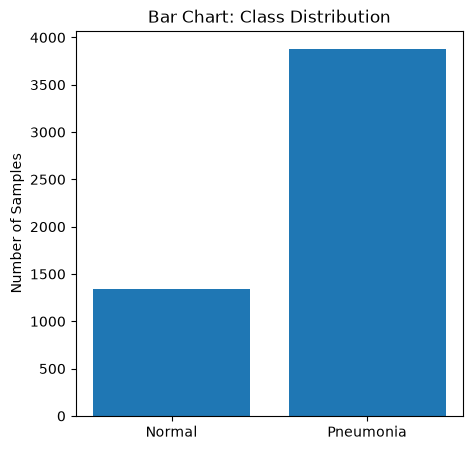

In [64]:
full_train_labels = [label for _, label in full_train_dataset.samples]

class_counts = Counter(full_train_labels)

plt.figure(figsize = (5, 5))

plt.title("Bar Chart: Class Distribution")

plt.bar(["Normal", "Pneumonia"], class_counts.values())
plt.ylabel("Number of Samples")

plt.show()

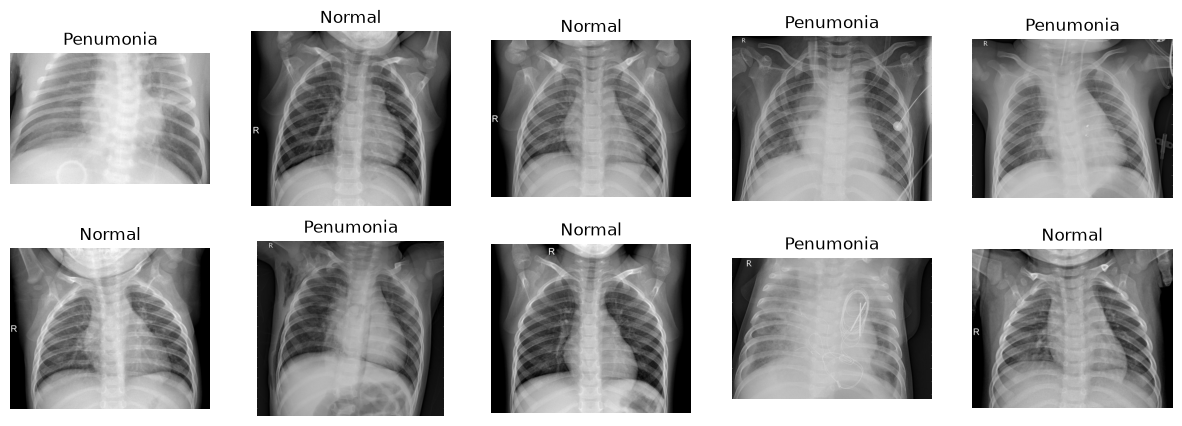

In [65]:
fig, axes = plt.subplots(2, 5, figsize = (15, 5))

for i in range(2):
    for j in range(5):
        rand_int = random.randint(0, len(full_train_dataset) - 1)
        img, label = full_train_dataset[rand_int]

        axes[i, j].set_title("Normal" if label == 0 else "Penumonia")
        axes[i, j].imshow(img, cmap = "gray")
        axes[i, j].axis("off")


## Data Preprocessing

### Train Validation Split

In [ ]:
full_train_labels = [label for _, label in full_train_dataset.samples]

indices = list(range(len(full_train_dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size = 0.2,
    random_state = 67,
    stratify = full_train_labels
)

### Dataset Creation

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

other_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [8]:
train_dataset = Subset(
    PneumoniaDataset("../data/train", transform = train_transform),
    train_idx
)

val_dataset = Subset(
    PneumoniaDataset("../data/train", transform = other_transform),
    val_idx
)

test_dataset = PneumoniaDataset("../data/test", transform = other_transform)

In [ ]:
# Without Custom Dataset
"""
train_dataset = ImageFolder(
    root = "../data/train",
    transform = transform
)
val_dataset = ImageFolder(
    root = "../data/val",
    transform = transform
)
test_dataset = ImageFolder(
    root = "../data/test",
    transform = transform
)

"""

### Handling Data Imbalance

In [ ]:
class_counts = Counter(full_train_labels)

num_samples = len(full_train_labels)

class_weights = {
    cls: num_samples / count for cls, count in class_counts.items()
}

sample_weights = [ class_weights[label] for label in full_train_labels]

In [7]:
sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

### Loading Data into Dataloaders

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    sampler = sampler,
    # shuffle = True, # ordering is handled by sampler so shuffle not needed
    # num_workers = 4,
    # pin_memory = True
    # drop_last = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False,
    # num_workers = 4,
    # pin_memory = True
    # drop_last = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False,
    # num_workers = 4,
    # pin_memory = True
    # drop_last = True
)